2.1

In [6]:

import matplotlib.pyplot as plt
import numpy as np
try:

    import torch

    import torchvision
    from torchvision import datasets, transforms

    from einops import rearrange

    from mpl_toolkits.mplot3d import Axes3D
    HAS_TORCH = True

except ImportError:

    HAS_TORCH = False
    print('error')


np.random.seed(42)
if HAS_TORCH:
    torch.manual_seed(42)

In [7]:

if HAS_TORCH:
    transform = transforms.Compose([transforms.ToTensor()])


    mnist_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
    indices = torch.randperm(len(mnist_dataset))[:1000]

    subset_dataset = torch.utils.data.Subset(mnist_dataset, indices)
    images = []
    labels = []
    for idx in range(len(subset_dataset)):


        img, label = subset_dataset[idx]
        images.append(img.squeeze().numpy())
        labels.append(label)
    images = np.array(images)


    labels = np.array(labels)
    print(f"Subset: {images.shape}")
    print(f"Labels: {labels.shape}")


    print(f"Image: [{images.min():.2f}, {images.max():.2f}]")
else:
    images = labels = None


    print('error')

100%|██████████| 9.91M/9.91M [00:00<00:00, 15.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 460kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.32MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.8MB/s]


Subset: (1000, 28, 28)
Labels: (1000,)
Image: [0.00, 1.00]


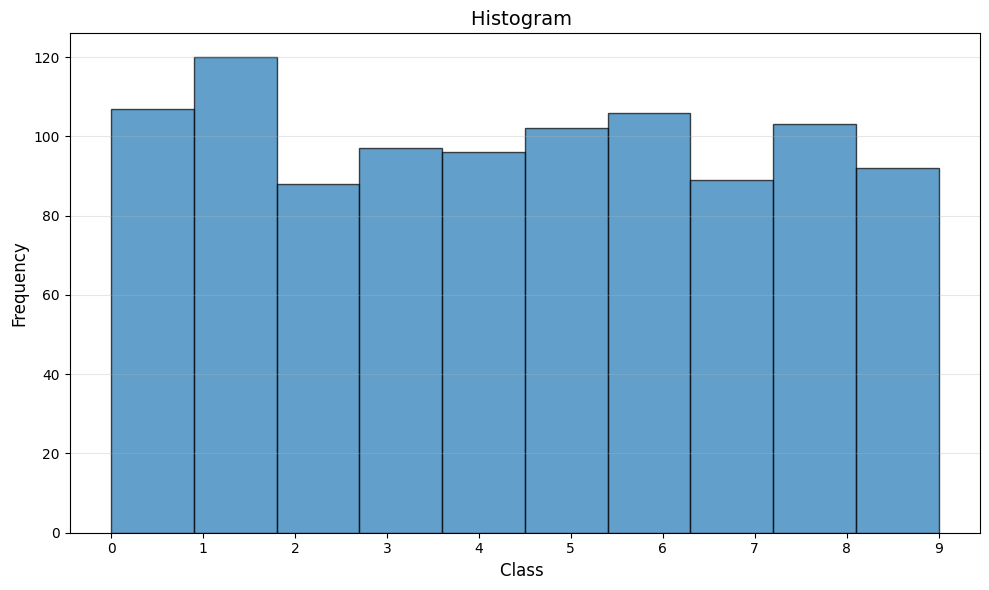

  Class 0: 107 samples
  Class 1: 120 samples
  Class 2: 88 samples
  Class 3: 97 samples
  Class 4: 96 samples
  Class 5: 102 samples
  Class 6: 106 samples
  Class 7: 89 samples
  Class 8: 103 samples
  Class 9: 92 samples


In [8]:

if HAS_TORCH and labels is not None:
    plt.figure(figsize=(10, 6))
    plt.hist(labels, bins=10, edgecolor='black', alpha=0.7)
    plt.xlabel('Class ', fontsize=12)


    plt.ylabel('Frequency', fontsize=12)
    plt.title('Histogram ', fontsize=14)



    plt.xticks(range(10))
    plt.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()



    for i in range(10):
        count = np.sum(labels == i)
        print(f"  Class {i}: {count} samples")
else:
    print('error')

In [9]:

if HAS_TORCH and images is not None:
    batch_size = 25
    num_batches = len(images) // batch_size

    images_with_channel = images[:, np.newaxis, :, :]
    batched_images = rearrange(images_with_channel, '(b n) c h w -> b n c h w', b=num_batches, n=batch_size)



    print(f"Original: {images.shape}")
    print(f"Batched: {batched_images.shape}")


    print(f"Numbers: {num_batches}")
else:
    print('error')

Original: (1000, 28, 28)
Batched: (40, 25, 1, 28, 28)
Numbers: 40


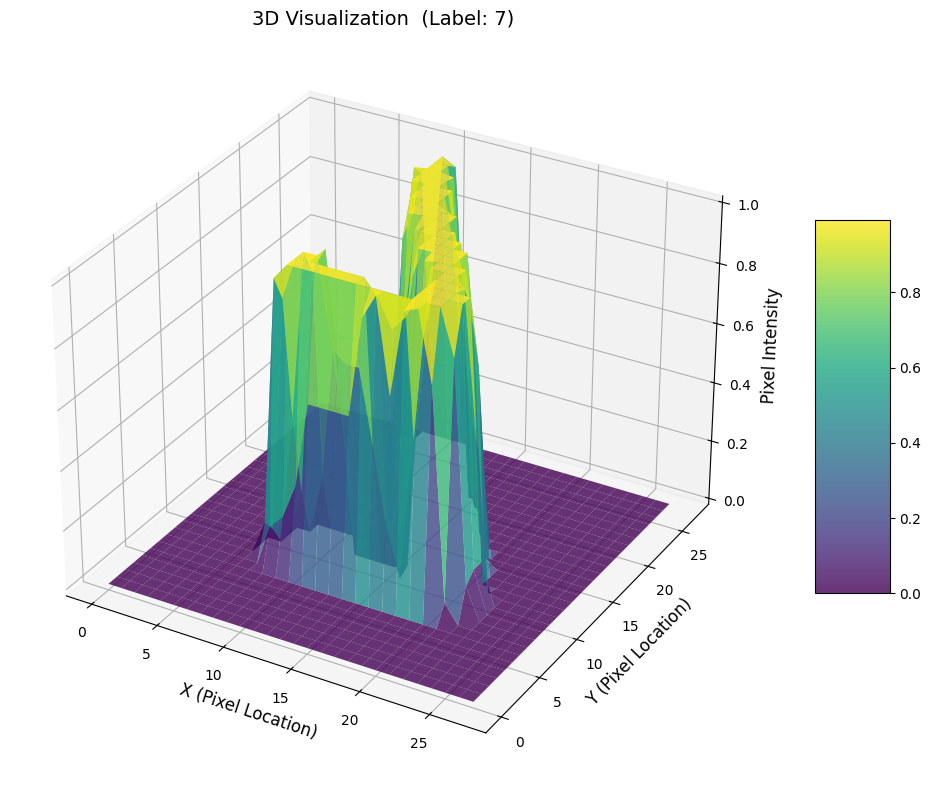

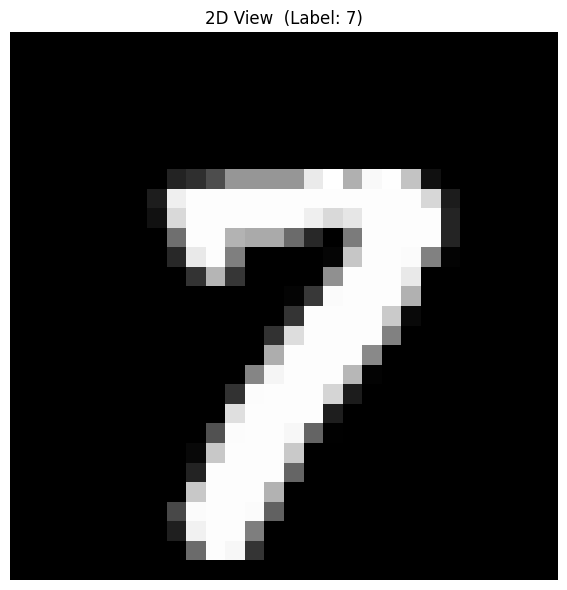

In [10]:

if HAS_TORCH and images is not None:
    random_idx = np.random.randint(0, len(images))
    selected_image = images[random_idx]
    selected_label = labels[random_idx]
    x = np.arange(28)


    y = np.arange(28)
    X, Y = np.meshgrid(x, y)
    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')
    surf = ax.plot_surface(X, Y, selected_image, cmap='viridis', linewidth=0, antialiased=True, alpha=0.8)


    ax.set_xlabel('X (Pixel Location)', fontsize=12)



    ax.set_ylabel('Y (Pixel Location)', fontsize=12)
    ax.set_zlabel('Pixel Intensity', fontsize=12)
    ax.set_title(f'3D Visualization  (Label: {selected_label})', fontsize=14)



    fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5)
    plt.tight_layout()
    plt.show()



    plt.figure(figsize=(6, 6))
    plt.imshow(selected_image, cmap='gray')


    plt.title(f'2D View  (Label: {selected_label})', fontsize=12)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

else:
    print('error')

2.2

In [11]:

import pandas as pd
import seaborn as sns


from datetime import datetime


plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")



try:
    energy_data = pd.read_csv('energydata_complete.csv', parse_dates=['date'])
    print(f"Done")
    print(f"Shape: {energy_data.shape}")



    print(f"\nColumns:")
    print(energy_data.columns.tolist())
    print(f"\nrows:")


    print(energy_data.head())


    print(f"\nInfo:")
    print(energy_data.info())
except FileNotFoundError:
    print("error")

Done
Shape: (19735, 29)

Columns:
['date', 'Appliances', 'lights', 'T1', 'RH_1', 'T2', 'RH_2', 'T3', 'RH_3', 'T4', 'RH_4', 'T5', 'RH_5', 'T6', 'RH_6', 'T7', 'RH_7', 'T8', 'RH_8', 'T9', 'RH_9', 'T_out', 'Press_mm_hg', 'RH_out', 'Windspeed', 'Visibility', 'Tdewpoint', 'rv1', 'rv2']

rows:
                 date  Appliances  lights     T1       RH_1    T2       RH_2  \
0 2016-01-11 17:00:00          60      30  19.89  47.596667  19.2  44.790000   
1 2016-01-11 17:10:00          60      30  19.89  46.693333  19.2  44.722500   
2 2016-01-11 17:20:00          50      30  19.89  46.300000  19.2  44.626667   
3 2016-01-11 17:30:00          50      40  19.89  46.066667  19.2  44.590000   
4 2016-01-11 17:40:00          60      40  19.89  46.333333  19.2  44.530000   

      T3       RH_3         T4  ...         T9   RH_9     T_out  Press_mm_hg  \
0  19.79  44.730000  19.000000  ...  17.033333  45.53  6.600000        733.5   
1  19.79  44.790000  19.000000  ...  17.066667  45.56  6.483333        

column: Appliances


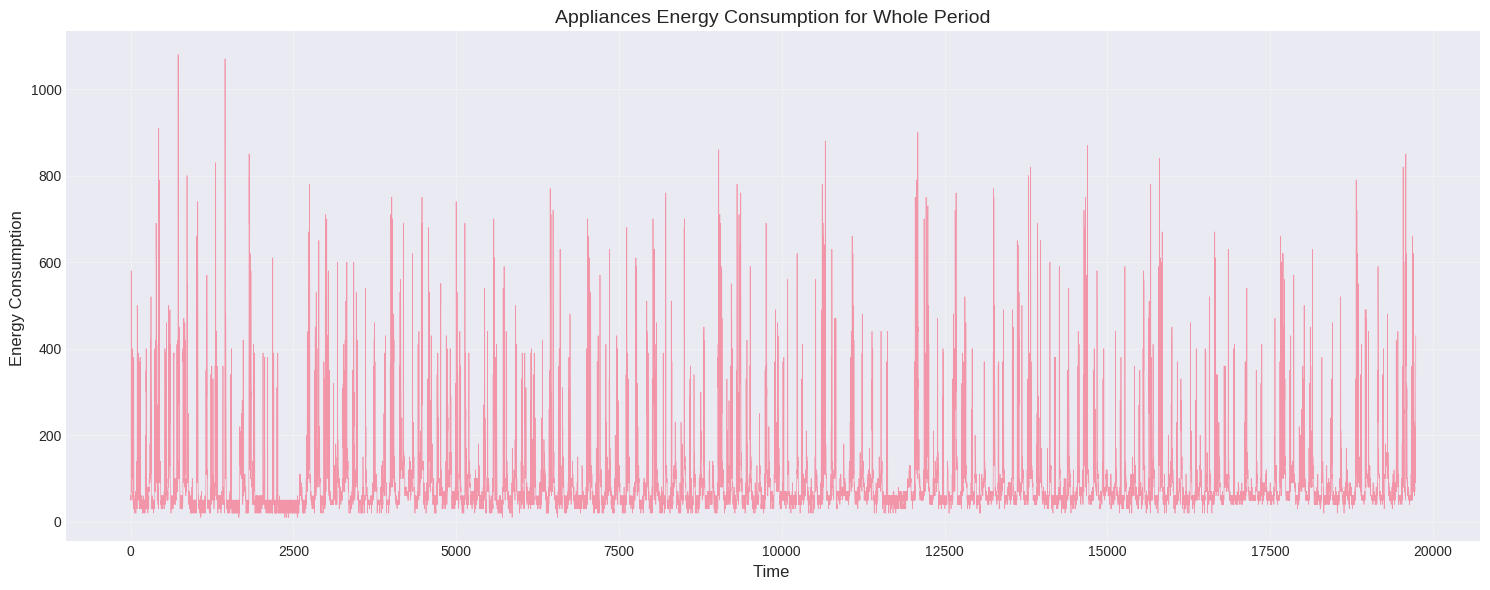

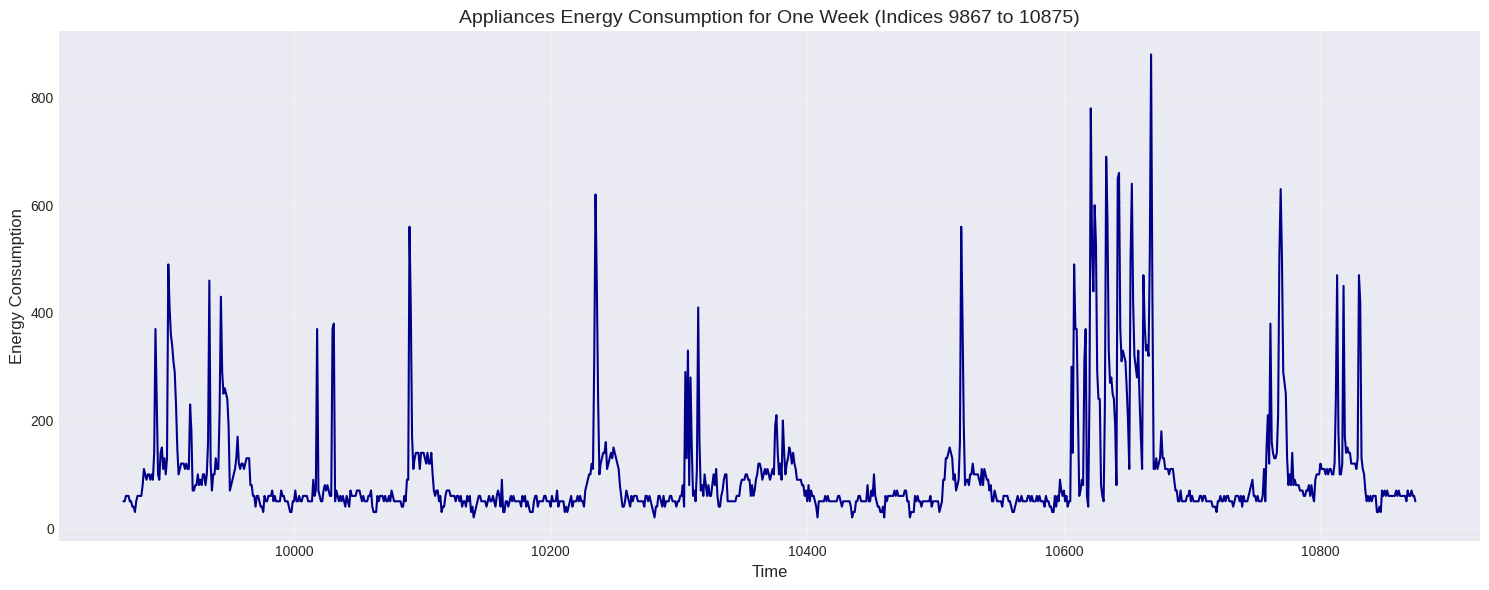

Week period: 1008
week: 9867 - 10875


In [12]:
if 'date' in energy_data.columns:


    energy_data['date'] = pd.to_datetime(energy_data['date'])


    energy_data = energy_data.sort_values('date').reset_index(drop=True)


appliances_col = None
for col in energy_data.columns:
    if 'appliances' in col.lower() or 'Appliances' in col:
        appliances_col = col
        break

if appliances_col is None:
    print("columns:", energy_data.columns.tolist())


else:
    print(f"column: {appliances_col}")


    plt.figure(figsize=(15, 6))
    plt.plot(energy_data.index, energy_data[appliances_col], linewidth=0.5, alpha=0.7)



    plt.xlabel('Time ', fontsize=12)
    plt.ylabel('Energy Consumption ', fontsize=12)


    plt.title('Appliances Energy Consumption for Whole Period', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


    week_size = 7 * 24 * 6
    start_idx = len(energy_data) // 2
    end_idx = min(start_idx + week_size, len(energy_data))

    plt.figure(figsize=(15, 6))
    plt.plot(energy_data.index[start_idx:end_idx],
             energy_data[appliances_col].iloc[start_idx:end_idx],
             linewidth=1.5, color='darkblue')
    plt.xlabel('Time', fontsize=12)
    plt.ylabel('Energy Consumption', fontsize=12)


    plt.title(f'Appliances Energy Consumption for One Week (Indices {start_idx} to {end_idx})', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f"Week period: {week_size}")



    print(f"week: {start_idx} - {end_idx}")

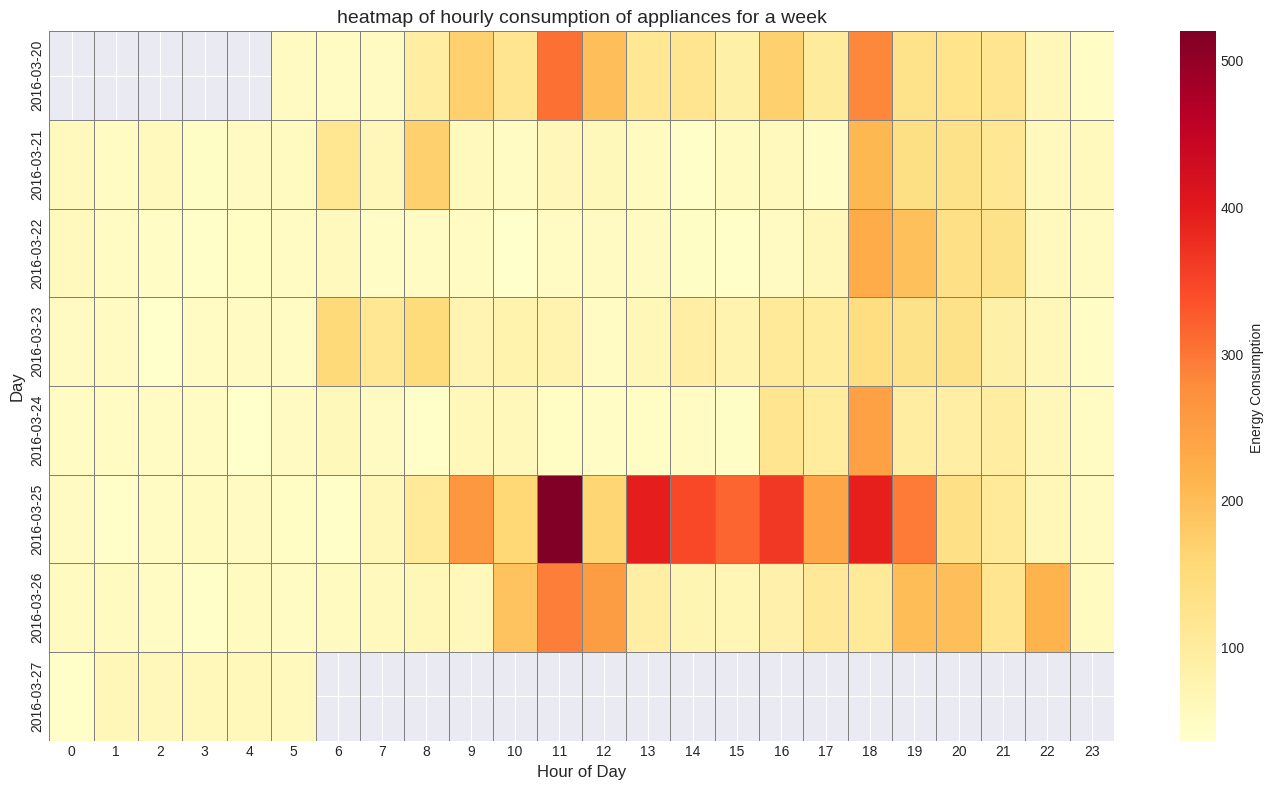

week period ( 9867 - 10875)


In [13]:
if appliances_col:

    if 'date' in energy_data.columns:
        energy_data['hour'] = energy_data['date'].dt.hour
        energy_data['day_of_week'] = energy_data['date'].dt.dayofweek

        energy_data['date_only'] = energy_data['date'].dt.date
    else:

        energy_data['hour'] = (energy_data.index % (24 * 6)) // 6
        energy_data['day_of_week'] = (energy_data.index // (24 * 6)) % 7
        energy_data['day_index'] = energy_data.index // (24 * 6)


    week_size = 7 * 24 * 6
    start_idx = len(energy_data) // 2
    end_idx = min(start_idx + week_size, len(energy_data))
    week_data = energy_data.iloc[start_idx:end_idx].copy()


    if 'date_only' in week_data.columns:
        pivot_data = week_data.pivot_table(
            values=appliances_col,
            index='date_only',
            columns='hour',
            aggfunc='mean'
        )
    else:

        pivot_data = week_data.pivot_table(
            values=appliances_col,
            index='day_index',
            columns='hour',



            aggfunc='mean'
        )


    plt.figure(figsize=(14, 8))
    sns.heatmap(pivot_data, cmap='YlOrRd', cbar_kws={'label': 'Energy Consumption '},
                linewidths=0.5, linecolor='gray', fmt='.1f')
    plt.xlabel('Hour of Day', fontsize=12)




    plt.ylabel('Day', fontsize=12)
    plt.title('heatmap of hourly consumption of appliances for a week', fontsize=14)


    plt.tight_layout()
    plt.show()

    print(f"week period ( {start_idx} - {end_idx})")

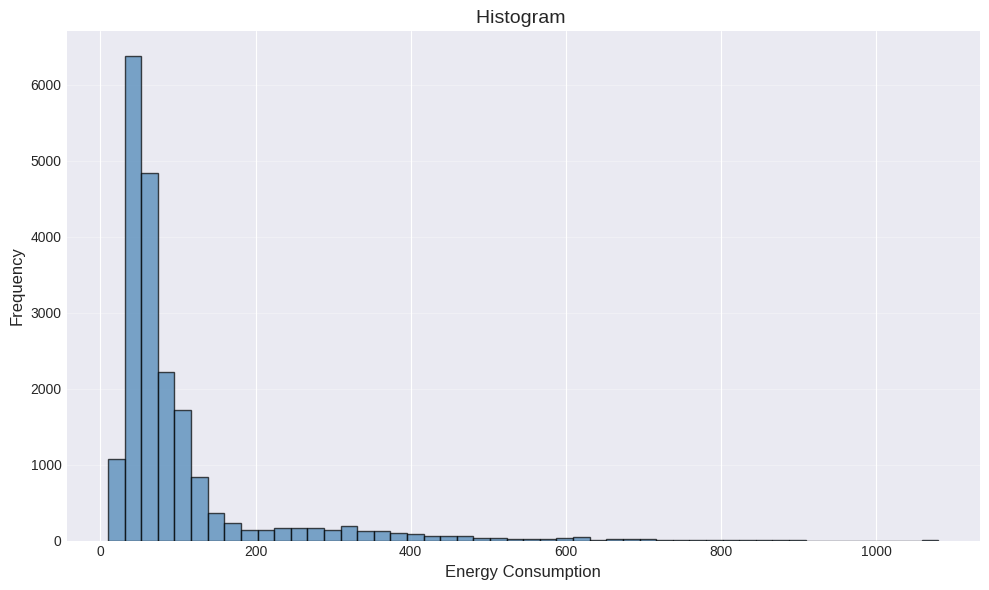

Statistics  Appliances:
  Mean: 97.69 Wh
  Median: 60.00 Wh
  Std: 102.52 Wh
  Min: 10.00 Wh
  Max: 1080.00 Wh


In [14]:

if appliances_col:
    plt.figure(figsize=(10, 6))
    plt.hist(energy_data[appliances_col], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
    plt.xlabel('Energy Consumption', fontsize=12)
    plt.ylabel('Frequency', fontsize=12)



    plt.title('Histogram ', fontsize=14)
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()


    print(f"Statistics  {appliances_col}:")


    print(f"  Mean: {energy_data[appliances_col].mean():.2f} Wh")
    print(f"  Median: {energy_data[appliances_col].median():.2f} Wh")
    print(f"  Std: {energy_data[appliances_col].std():.2f} Wh")



    print(f"  Min: {energy_data[appliances_col].min():.2f} Wh")
    print(f"  Max: {energy_data[appliances_col].max():.2f} Wh")

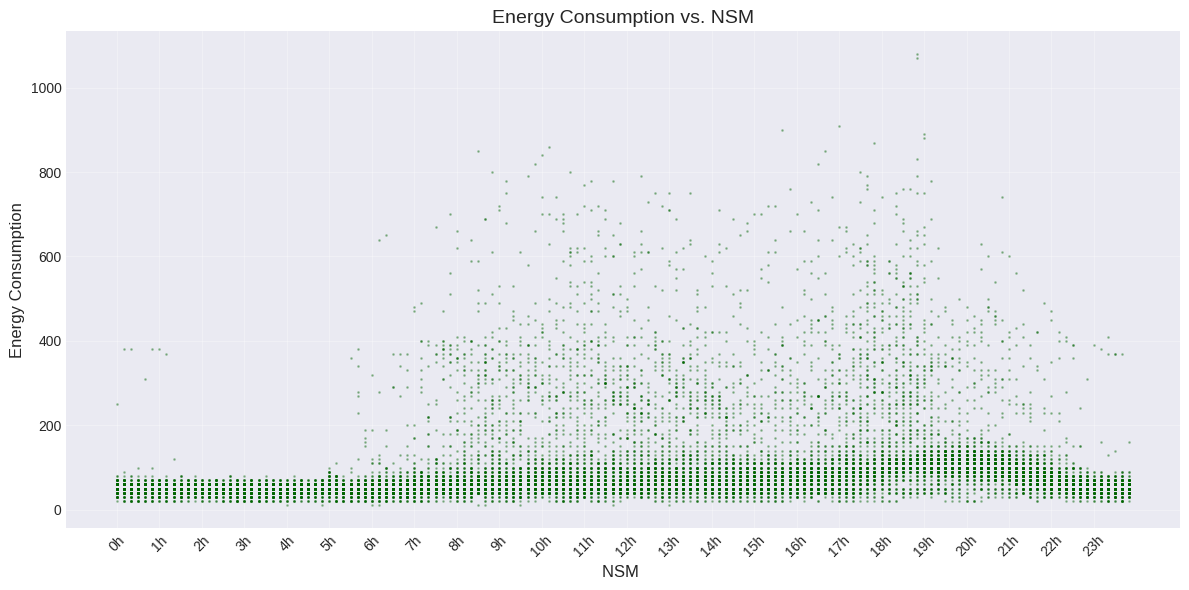

range: 0 to 85800 seconds


In [15]:
if appliances_col:

    if 'date' in energy_data.columns:
        energy_data['NSM'] = (energy_data['date'].dt.hour * 3600 +
                              energy_data['date'].dt.minute * 60 +


                              energy_data['date'].dt.second)
    else:

        energy_data['NSM'] = (energy_data.index % (24 * 6)) * 600


    plt.figure(figsize=(12, 6))
    plt.scatter(energy_data['NSM'], energy_data[appliances_col],



                alpha=0.3, s=1, color='darkgreen')
    plt.xlabel('NSM ', fontsize=12)
    plt.ylabel('Energy Consumption', fontsize=12)
    plt.title('Energy Consumption vs. NSM', fontsize=14)
    plt.grid(True, alpha=0.3)


    ax = plt.gca()
    hour_ticks = np.arange(0, 86400, 3600)
    ax.set_xticks(hour_ticks)



    ax.set_xticklabels([f'{h//3600}h' for h in hour_ticks], rotation=45)

    plt.tight_layout()
    plt.show()

    print(f"range: {energy_data['NSM'].min()} to {energy_data['NSM'].max()} seconds")


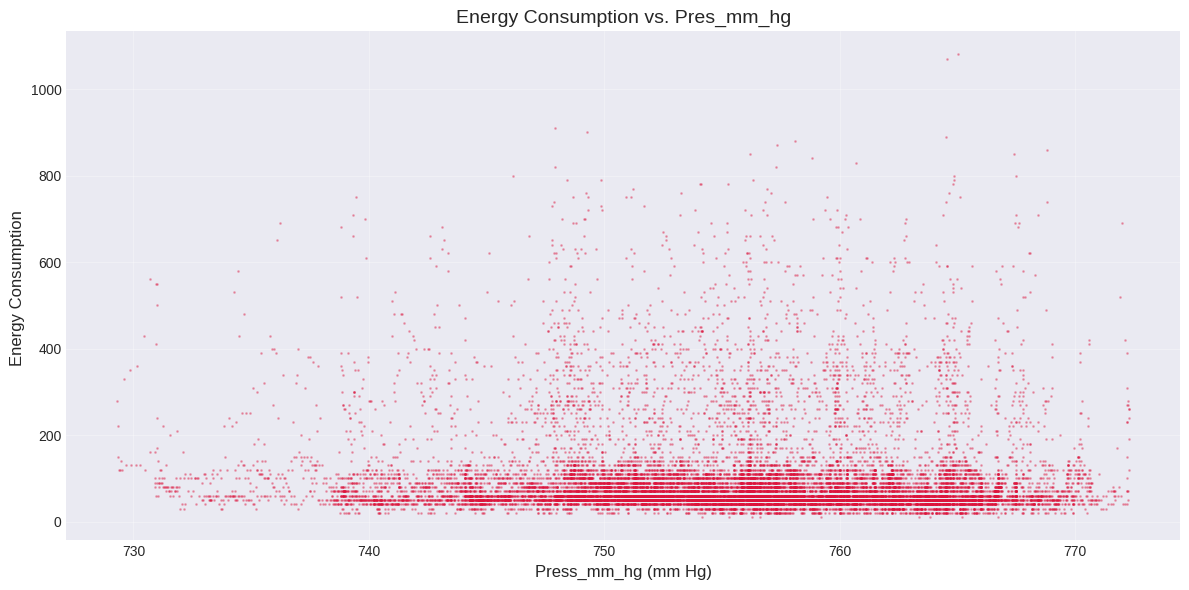

Correlation  Press_mm_hg and Appliances: -0.0349


In [16]:
if appliances_col:

    press_col = None
    for col in energy_data.columns:
        if 'press' in col.lower() or 'Press' in col or 'pressure' in col.lower():
            press_col = col
            break




    if press_col:
        plt.figure(figsize=(12, 6))
        plt.scatter(energy_data[press_col], energy_data[appliances_col],
                    alpha=0.3, s=1, color='crimson')


        plt.xlabel(f'{press_col} (mm Hg)', fontsize=12)
        plt.ylabel('Energy Consumption ', fontsize=12)
        plt.title('Energy Consumption vs. Pres_mm_hg', fontsize=14)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()


        correlation = energy_data[press_col].corr(energy_data[appliances_col])



        print(f"Correlation  {press_col} and {appliances_col}: {correlation:.4f}")
    else:
        print("error")
        print(energy_data.columns.tolist())

# Comment: I found that NSM has a correlation of 0.2172, so time of day clearly affects energy usage. Energy consumption follows a daily pattern — higher during active hours and lower at night.Press_mm_hg has a very small correlation (-0.0349), so it does not strongly affect energy consumption.Overall, time of day (NSM) is a much more important factor than pressure.

2.3

In [18]:
from scipy import stats





try:

    airfoil_data = pd.read_csv('airfoil_self_noise.dat', sep='\s+', header=None,
                               names=['Frequency', 'Angle_of_attack', 'Chord_length',
                                      'Free_stream_velocity', 'Suction_side_displacement_thickness',
                                      'Scaled_sound_pressure_level'])

    print(f"Shape: {airfoil_data.shape}")
    print(f"\n rows:")
    print(airfoil_data.head())
    print(f"\ninfo:")
    print(airfoil_data.info())




    print(f"\nstatistics:")
    print(airfoil_data.describe())



except FileNotFoundError:
    print("error")


Shape: (1503, 6)

 rows:
   Frequency  Angle_of_attack  Chord_length  Free_stream_velocity  \
0        800              0.0        0.3048                  71.3   
1       1000              0.0        0.3048                  71.3   
2       1250              0.0        0.3048                  71.3   
3       1600              0.0        0.3048                  71.3   
4       2000              0.0        0.3048                  71.3   

   Suction_side_displacement_thickness  Scaled_sound_pressure_level  
0                             0.002663                      126.201  
1                             0.002663                      125.201  
2                             0.002663                      125.951  
3                             0.002663                      127.591  
4                             0.002663                      127.461  

info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1503 entries, 0 to 1502
Data columns (total 6 columns):
 #   Column                

<>:9: SyntaxWarning: invalid escape sequence '\s'
<>:9: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-3830966303.py:9: SyntaxWarning: invalid escape sequence '\s'
  airfoil_data = pd.read_csv('airfoil_self_noise.dat', sep='\s+', header=None,


In [19]:
if 'airfoil_data' in locals():

    stats_dict = {}

    for col in airfoil_data.columns:
        data = airfoil_data[col]
        stats_dict[col] = {
            'Mean': data.mean(),
            'Variance': data.var(),



            'Standard_Deviation': data.std(),
            'Median': data.median(),
            'Kurtosis': stats.kurtosis(data),
            'Skewness': stats.skew(data),



            'Range': data.max() - data.min(),
            'Min': data.min(),
            'Max': data.max()
        }


    stats_df = pd.DataFrame(stats_dict).T


    print("\n" + stats_df.to_string())



    for col in airfoil_data.columns:
        print(f"\n{col}:")
        print(f"  Mean: {stats_dict[col]['Mean']:.6f}")
        print(f"  Variance: {stats_dict[col]['Variance']:.6f}")
        print(f"  Standard Deviation: {stats_dict[col]['Standard_Deviation']:.6f}")
        print(f"  Median: {stats_dict[col]['Median']:.6f}")




        print(f"  Kurtosis: {stats_dict[col]['Kurtosis']:.6f}")
        print(f"  Skewness: {stats_dict[col]['Skewness']:.6f}")
        print(f"  Range: {stats_dict[col]['Range']:.6f} (Min: {stats_dict[col]['Min']:.6f}, Max: {stats_dict[col]['Max']:.6f})")




                                            Mean      Variance  Standard_Deviation       Median  Kurtosis  Skewness         Range         Min           Max
Frequency                            2886.380572  9.938717e+06         3152.573137  1600.000000  5.685722  2.134951  19800.000000  200.000000  20000.000000
Angle_of_attack                         6.782302  3.502424e+01            5.918128     5.400000 -0.415568  0.688476     22.200000    0.000000     22.200000
Chord_length                            0.136548  8.749868e-03            0.093541     0.101600 -1.038504  0.457001      0.279400    0.025400      0.304800
Free_stream_velocity                   50.860745  2.425116e+02           15.572784    39.600000 -1.562743  0.235617     39.600000   31.700000     71.300000
Suction_side_displacement_thickness     0.011140  1.729287e-04            0.013150     0.004957  2.207539  1.700465      0.058011    0.000401      0.058411
Scaled_sound_pressure_level           124.835943  4.759146e+01 

3.1

Extracted Agricultural_Image_Analytics.zip to agricultural_images
 13 files

shape: (4864, 3648)
 mode: RGB


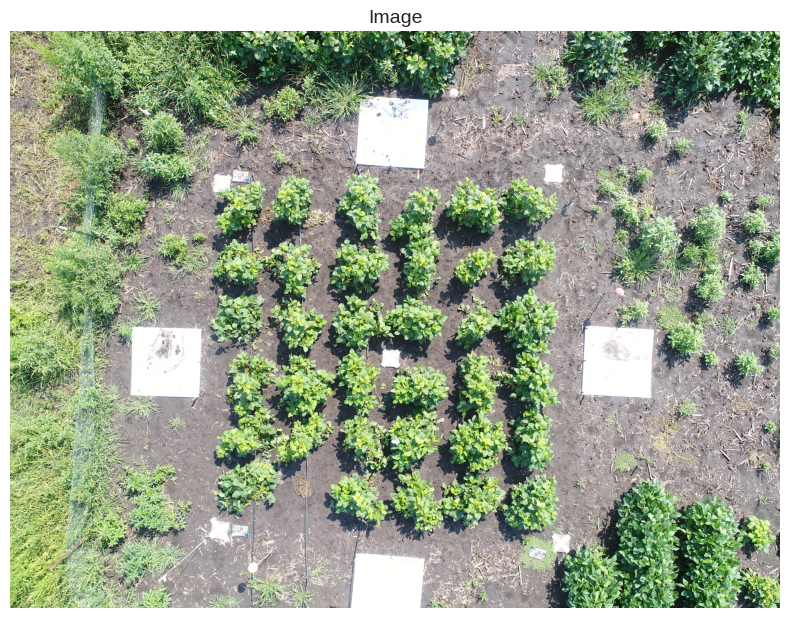

In [20]:
from PIL import Image
import cv2
from scipy import ndimage
from scipy.ndimage import map_coordinates



import zipfile
import os
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


np.random.seed(42)
zip_path = 'Agricultural_Image_Analytics.zip'
extracted_dir = 'agricultural_images'




try:

    if not os.path.exists(extracted_dir):
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:



            zip_ref.extractall(extracted_dir)
        print(f"Extracted {zip_path} to {extracted_dir}")


    image_files = []
    for root, dirs, files in os.walk(extracted_dir):
        if '__MACOSX' in root:
            continue
        for file in files:




            if file.startswith('._'):
                continue
            if file.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tiff')):
                image_files.append(os.path.join(root, file))

    print(f" {len(image_files)} files")





    if image_files:
        sample_image = Image.open(image_files[0])
        print(f"\nshape: {sample_image.size}")

        print(f" mode: {sample_image.mode}")





        plt.figure(figsize=(8, 8))


        plt.imshow(sample_image)
        plt.title('Image', fontsize=14)
        plt.axis('off')
        plt.tight_layout()



        plt.show()

except FileNotFoundError:
    print(f"error")
    p
except Exception as e:
    print(f"error {e}")



In [21]:
def random_rotate(image, max_angle=30):

    angle = np.random.uniform(-max_angle, max_angle)



    return image.rotate(angle, resample=Image.BILINEAR)

def random_shift(image, max_shift=0.1):

    img_array = np.array(image)
    h, w = img_array.shape[:2]
    shift_x = int(np.random.uniform(-max_shift, max_shift) * w)



    shift_y = int(np.random.uniform(-max_shift, max_shift) * h)

    M = np.float32([[1, 0, shift_x], [0, 1, shift_y]])



    if len(img_array.shape) == 3:
        shifted = cv2.warpAffine(img_array, M, (w, h))
    else:
        shifted = cv2.warpAffine(img_array, M, (w, h))
    return Image.fromarray(shifted)

def random_scale(image, scale_range=(0.8, 1.2)):

    img_array = np.array(image)
    h, w = img_array.shape[:2]



    scale = np.random.uniform(scale_range[0], scale_range[1])
    new_w, new_h = int(w * scale), int(h * scale)

    scaled = cv2.resize(img_array, (new_w, new_h), interpolation=cv2.INTER_LINEAR)


    if scale < 1:

        pad_h = (h - new_h) // 2
        pad_w = (w - new_w) // 2


        if len(scaled.shape) == 3:
            padded = np.pad(scaled, ((pad_h, h - new_h - pad_h),
                                     (pad_w, w - new_w - pad_w), (0, 0)), mode='reflect')
        else:
            padded = np.pad(scaled, ((pad_h, h - new_h - pad_h),
                                     (pad_w, w - new_w - pad_w)), mode='reflect')
        return Image.fromarray(padded)
    else:

        start_h = (new_h - h) // 2



        start_w = (new_w - w) // 2
        cropped = scaled[start_h:start_h+h, start_w:start_w+w]
        return Image.fromarray(cropped)

def random_warp(image, warp_strength=0.1):

    img_array = np.array(image)
    h, w = img_array.shape[:2]


    x = np.arange(w)
    y = np.arange(h)
    X, Y = np.meshgrid(x, y)


    displacement_x = np.random.uniform(-warp_strength * w, warp_strength * w, (h, w))
    displacement_y = np.random.uniform(-warp_strength * h, warp_strength * h, (h, w))

    X_new = X + displacement_x
    Y_new = Y + displacement_y


    if len(img_array.shape) == 3:



        warped = np.zeros_like(img_array)
        for c in range(img_array.shape[2]):
            warped[:, :, c] = map_coordinates(img_array[:, :, c],
                                              [Y_new.flatten(), X_new.flatten()],
                                              order=1, mode='reflect').reshape(h, w)
    else:
        warped = map_coordinates(img_array, [Y_new.flatten(), X_new.flatten()],
                                order=1, mode='reflect').reshape(h, w)

    return Image.fromarray(warped.astype(np.uint8))


if image_files:
    original_image = Image.open(image_files[0])
    transformed_images = []

    print("generate")
    for i in range(100):

        img = original_image.copy()


        if np.random.rand() > 0.5:
            img = random_rotate(img)
        if np.random.rand() > 0.5:
            img = random_shift(img)
        if np.random.rand() > 0.5:
            img = random_scale(img)
        if np.random.rand() > 0.5:
            img = random_warp(img)

        transformed_images.append(np.array(img))

        if (i + 1) % 20 == 0:
            print(f"  Generated {i + 1}/100 ")



    print(f" generated {len(transformed_images)} images")


    fig, axes = plt.subplots(2, 5, figsize=(20, 8))
    axes = axes.flatten()


    axes[0].imshow(original_image)
    axes[0].set_title('Original', fontsize=12)
    axes[0].axis('off')


    for i in range(1, 10):
        idx = np.random.randint(0, len(transformed_images))


        axes[i].imshow(transformed_images[idx])
        axes[i].set_title(f'Transformed {idx+1}', fontsize=12)
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("error")

Output hidden; open in https://colab.research.google.com to view.

 64x64 
Extracted 21921 
shape: (21921, 64, 64)


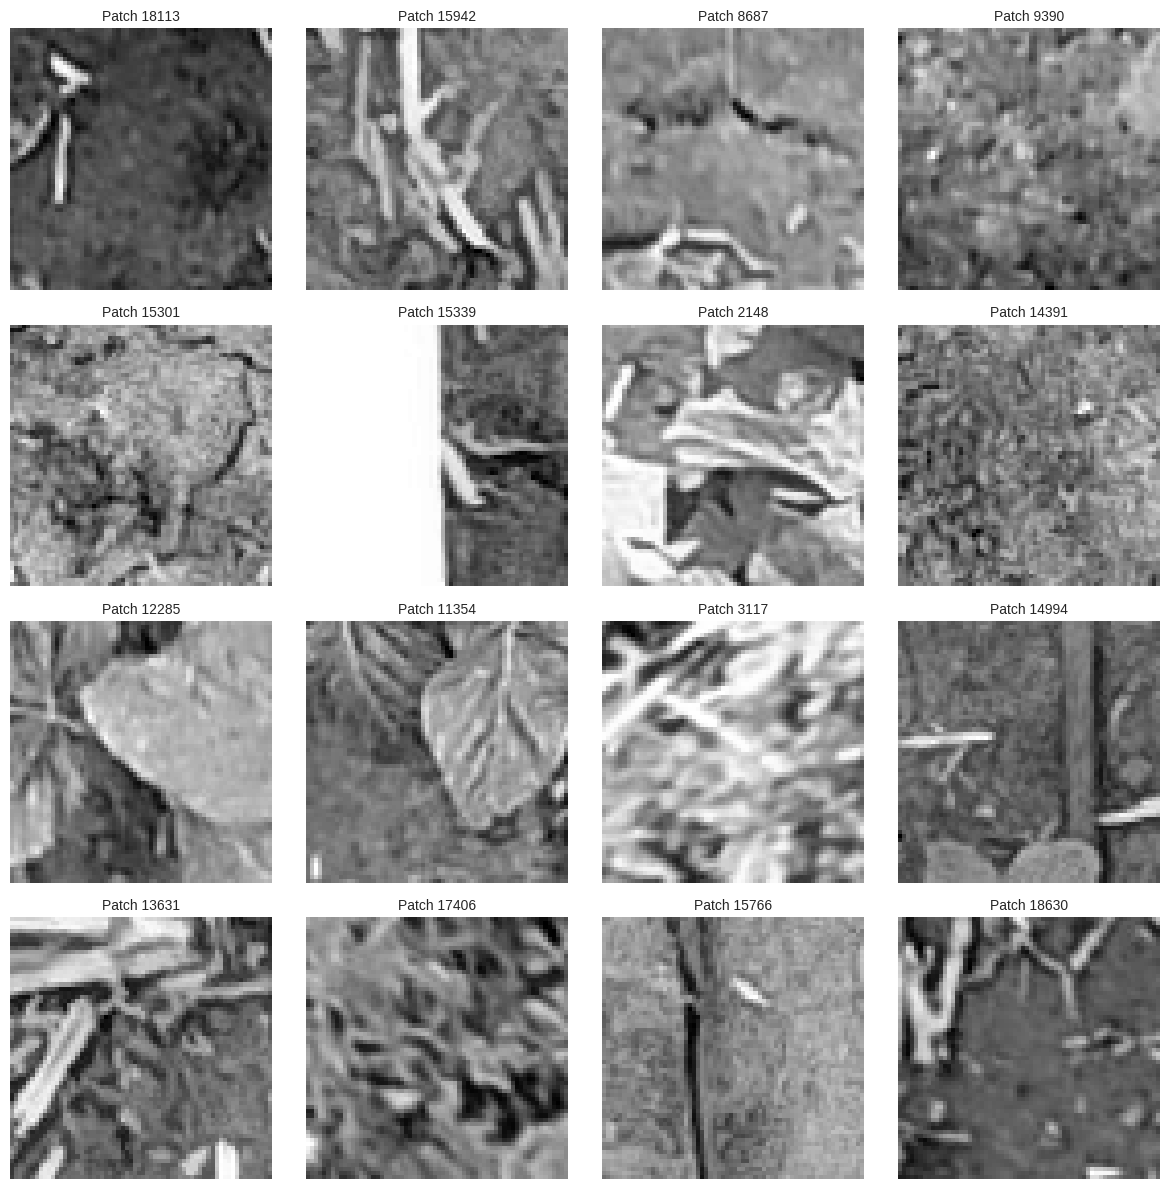

In [22]:
if image_files and len(image_files) > 0:
    patch_size = 64
    patches = []




    print(f" {patch_size}x{patch_size} ")

    for img_path in image_files:
        img = Image.open(img_path)


        img_array = np.array(img)




        if len(img_array.shape) == 3:
            img_gray = cv2.cvtColor(img_array, cv2.COLOR_RGB2GRAY)
        else:
            img_gray = img_array

        h, w = img_gray.shape


        if h >= patch_size and w >= patch_size:
            for y in range(0, h - patch_size + 1, patch_size):



                for x in range(0, w - patch_size + 1, patch_size):
                    patch = img_gray[y:y+patch_size, x:x+patch_size]
                    patches.append(patch)

    patches = np.array(patches)

    print(f"Extracted {len(patches)} ")




    print(f"shape: {patches.shape}")


    num_samples = min(16, len(patches))
    fig, axes = plt.subplots(4, 4, figsize=(12, 12))
    axes = axes.flatten()

    sample_indices = np.random.choice(len(patches), num_samples, replace=False)
    for i, idx in enumerate(sample_indices):
        axes[i].imshow(patches[idx], cmap='gray')
        axes[i].set_title(f'Patch {idx}', fontsize=10)
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("error")

loading
Original : (21921, 64, 64)
Whitened: (21921, 64, 64)


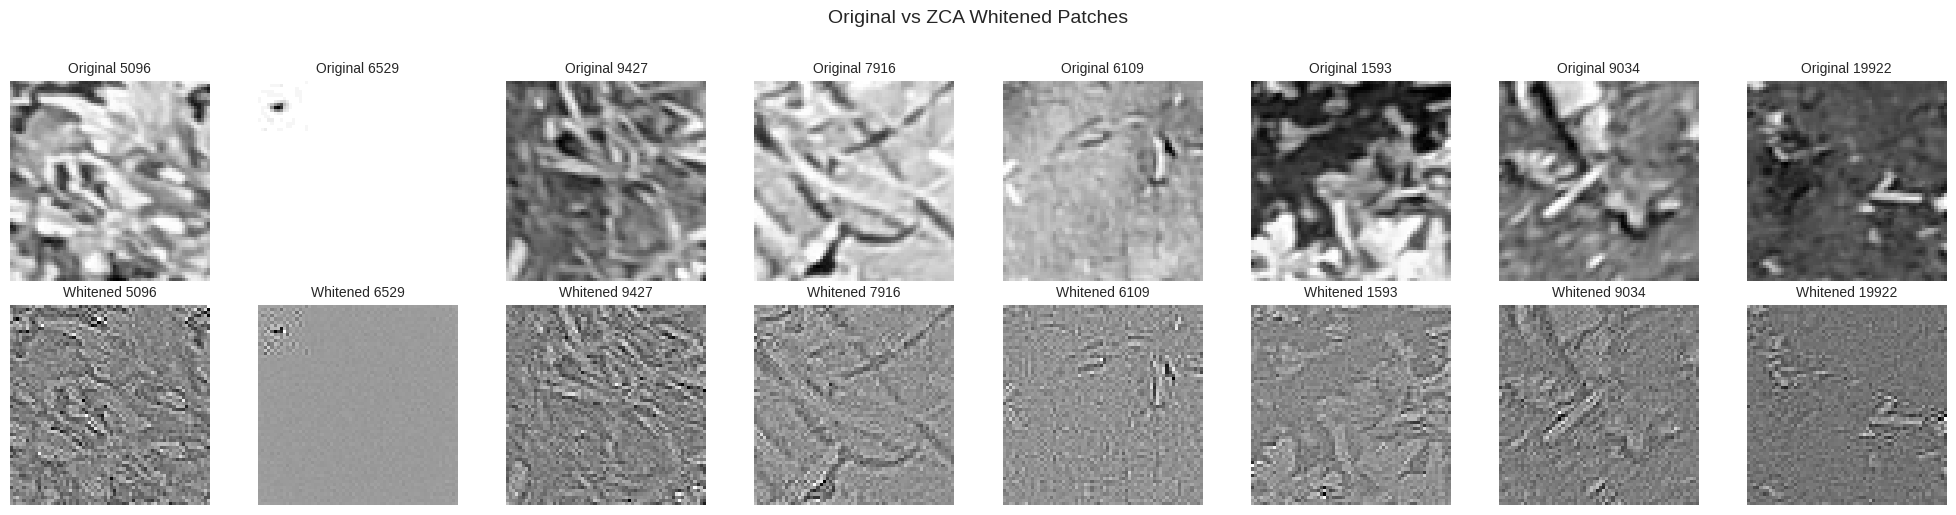

done


In [23]:
def zca_whitening(patches, epsilon=1e-5):

    original_shape = patches.shape


    if len(original_shape) == 3:
        N, H, W = original_shape
        patches_flat = patches.reshape(N, H * W)
    else:
        N, H, W, C = original_shape
        patches_flat = patches.reshape(N, H * W * C)


    mean = patches_flat.mean(axis=0, keepdims=True)
    patches_centered = patches_flat - mean


    cov = np.dot(patches_centered.T, patches_centered) / (N - 1)


    eigenvals, eigenvecs = np.linalg.eigh(cov)


    eigenvals = eigenvals + epsilon


    D_inv_sqrt = np.diag(1.0 / np.sqrt(eigenvals))
    W_zca = np.dot(eigenvecs, np.dot(D_inv_sqrt, eigenvecs.T))


    patches_whitened_flat = np.dot(patches_centered, W_zca.T)


    patches_whitened = patches_whitened_flat.reshape(original_shape)

    return patches_whitened, mean, W_zca

if 'patches' in locals() and len(patches) > 0:
    print("loading")
    patches_whitened, mean_patch, W_zca = zca_whitening(patches)

    print(f"Original : {patches.shape}")
    print(f"Whitened: {patches_whitened.shape}")


    fig, axes = plt.subplots(2, 8, figsize=(20, 5))


    sample_indices = np.random.choice(len(patches), 8, replace=False)
    for i, idx in enumerate(sample_indices):
        axes[0, i].imshow(patches[idx], cmap='gray')
        axes[0, i].set_title(f'Original {idx}', fontsize=10)
        axes[0, i].axis('off')


    for i, idx in enumerate(sample_indices):

        whitened_vis = patches_whitened[idx]
        whitened_vis = (whitened_vis - whitened_vis.min()) / (whitened_vis.max() - whitened_vis.min() + 1e-8)
        axes[1, i].imshow(whitened_vis, cmap='gray')
        axes[1, i].set_title(f'Whitened {idx}', fontsize=10)
        axes[1, i].axis('off')

    plt.suptitle('Original vs ZCA Whitened Patches', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

    print("done")
else:
    print("error")


1. Original Patches Distribution:
   Shape: (21921, 64, 64)
   Mean: 156.1830
   Std: 56.8215
   Min: 0
   Max: 255

2. Prewhitened Patches Distribution:
   Shape: (21921, 64, 64)
   Mean: -0.0000
   Std: 1.0000
   Min: -25.7984
   Max: 23.6315


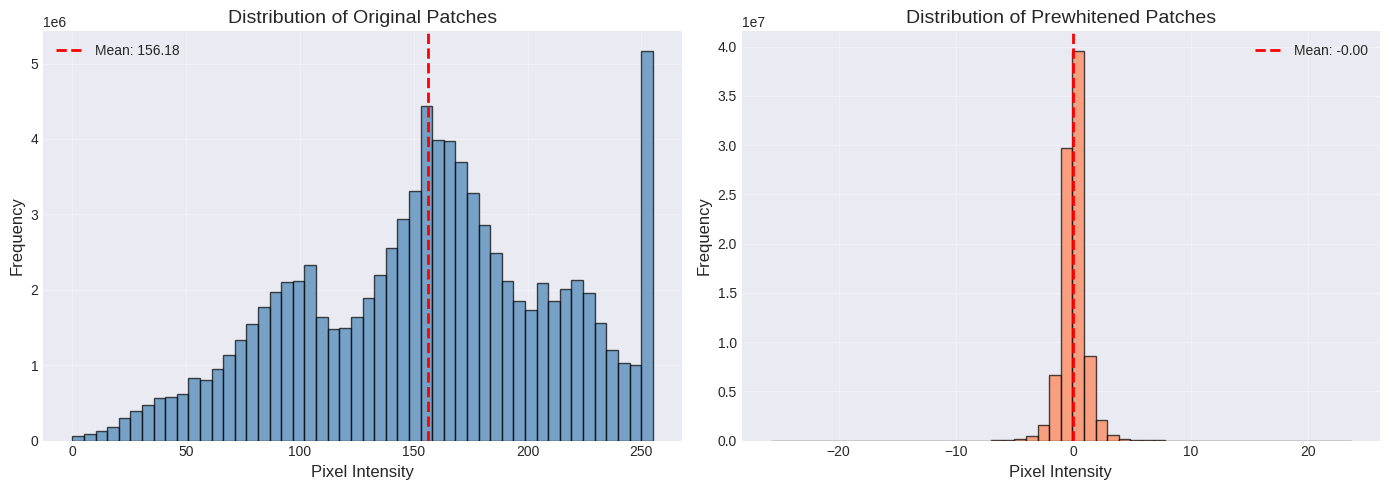


3. Statistical Comparison:
   Original - Skewness: -0.2062
   Original - Kurtosis: -0.5893
   Whitened - Skewness: 0.0740
   Whitened - Kurtosis: 6.6191


In [24]:
if 'patches' in locals() and len(patches) > 0 and 'patches_whitened' in locals():





    print("\n1. Original Patches Distribution:")
    print(f"   Shape: {patches.shape}")
    print(f"   Mean: {patches.mean():.4f}")
    print(f"   Std: {patches.std():.4f}")
    print(f"   Min: {patches.min():.0f}")
    print(f"   Max: {patches.max():.0f}")


    print("\n2. Prewhitened Patches Distribution:")
    print(f"   Shape: {patches_whitened.shape}")
    print(f"   Mean: {patches_whitened.mean():.4f}")
    print(f"   Std: {patches_whitened.std():.4f}")
    print(f"   Min: {patches_whitened.min():.4f}")
    print(f"   Max: {patches_whitened.max():.4f}")


    fig, axes = plt.subplots(1, 2, figsize=(14, 5))


    axes[0].hist(patches.flatten(), bins=50, edgecolor='black', alpha=0.7, color='steelblue')
    axes[0].axvline(patches.mean(), color='red', linestyle='--',
                    label=f'Mean: {patches.mean():.2f}', linewidth=2)
    axes[0].set_xlabel('Pixel Intensity', fontsize=12)
    axes[0].set_ylabel('Frequency', fontsize=12)
    axes[0].set_title('Distribution of Original Patches', fontsize=14)
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)


    axes[1].hist(patches_whitened.flatten(), bins=50, edgecolor='black', alpha=0.7, color='coral')
    axes[1].axvline(patches_whitened.mean(), color='red', linestyle='--',
                    label=f'Mean: {patches_whitened.mean():.2f}', linewidth=2)
    axes[1].set_xlabel('Pixel Intensity', fontsize=12)
    axes[1].set_ylabel('Frequency', fontsize=12)
    axes[1].set_title('Distribution of Prewhitened Patches', fontsize=14)
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


    print("\n3. Statistical Comparison:")
    print(f"   Original - Skewness: {stats.skew(patches.flatten()):.4f}")
    print(f"   Original - Kurtosis: {stats.kurtosis(patches.flatten()):.4f}")
    print(f"   Whitened - Skewness: {stats.skew(patches_whitened.flatten()):.4f}")
    print(f"   Whitened - Kurtosis: {stats.kurtosis(patches_whitened.flatten()):.4f}")



    if False:
        print("\n4. Analysis")
        for channel_idx, channel_name in enumerate(['Red', 'Green', 'Blue']):
            channel_data = patches[:, :, :, channel_idx]
            print(f"\n   {channel_name} Channel:")
            print(f"      Mean: {channel_data.mean():.4f}")
            print(f"      Std: {channel_data.std():.4f}")
else:
    print("error")

3.2

  Processed 5.JPG:  15 subplots
  Processed 2.JPG:  3 subplots
  Processed 4.JPG:  25 subplots
  Processed 1.JPG:  2 subplots
  Processed 3.JPG:  4 subplots


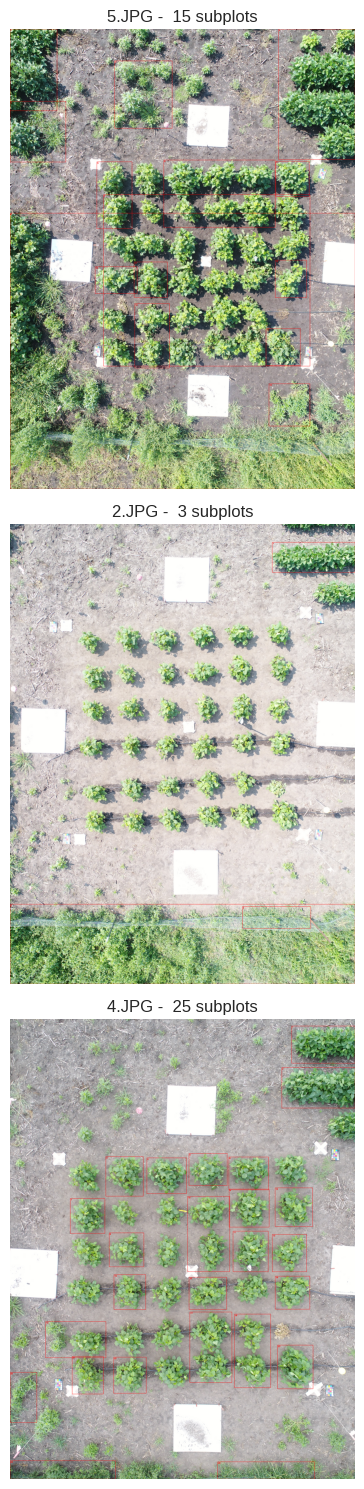

In [25]:
from scipy import ndimage
from scipy.ndimage import label, find_objects
from skimage import measure, morphology

def extract_soybean_subplots(image_path, num_subplots=36):

    img = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)


    lower_green = np.array([35, 50, 50])
    upper_green = np.array([85, 255, 255])


    mask = cv2.inRange(img_hsv, lower_green, upper_green)


    kernel = np.ones((5, 5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)


    labeled_mask, num_features = label(mask)


    regions = find_objects(labeled_mask)


    min_area = (img.shape[0] * img.shape[1]) / (num_subplots * 4)
    valid_regions = []

    for i, region in enumerate(regions):
        if region is not None:
            y_slice, x_slice = region
            area = (y_slice.stop - y_slice.start) * (x_slice.stop - x_slice.start)
            if area > min_area:
                valid_regions.append((region, i + 1))


    def get_sort_key(region_data):
        region, _ = region_data
        y_slice, x_slice = region

        return (y_slice.start // (img.shape[0] // 6), x_slice.start // (img.shape[1] // 6))

    valid_regions.sort(key=get_sort_key)


    valid_regions = valid_regions[:num_subplots]


    result_img = img_rgb.copy()
    for idx, (region, label_id) in enumerate(valid_regions):
        y_slice, x_slice = region


        cv2.rectangle(result_img,
                     (x_slice.start, y_slice.start),
                     (x_slice.stop, y_slice.stop),
                     (255, 0, 0), 2)


        subplot_num = idx + 1
        cv2.putText(result_img, str(subplot_num),
                   (x_slice.start + 5, y_slice.start + 20),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)

    return result_img, len(valid_regions)


if image_files:


    processed_images = []
    for img_path in image_files[:5]:
        try:
            result_img, num_found = extract_soybean_subplots(img_path, num_subplots=36)
            processed_images.append((result_img, num_found, os.path.basename(img_path)))
            print(f"  Processed {os.path.basename(img_path)}:  {num_found} subplots")
        except Exception as e:
            print(f"  Error  {os.path.basename(img_path)}: {e}")


    if processed_images:
        num_display = min(len(processed_images), 3)
        fig, axes = plt.subplots(num_display, 1, figsize=(15, 5 * num_display))
        if num_display == 1:
            axes = [axes]

        for i, (result_img, num_found, img_name) in enumerate(processed_images[:num_display]):
            axes[i].imshow(result_img)
            axes[i].set_title(f'{img_name} -  {num_found} subplots', fontsize=12)
            axes[i].axis('off')

        plt.tight_layout()
        plt.show()
    else:
        print("error")
else:
    print("error")